# GujEstateAI — Phase 5: Module 2 — Project Cost Estimation
**Input  :** `data/processed/features.csv` + `models/encoders.pkl`  
**Output :** `models/cost_model.pkl`  
**Goal   :** Predict total estimated cost of a construction project  
**Target :** `totalEstimatedCost` (via log transform)  
**Type   :** Regression  

Run cells one by one, top to bottom.
---

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import mean_absolute_error, r2_score
from xgboost                 import XGBRegressor
from lightgbm                import LGBMRegressor

# Fix torch DLL error before importing shap
import sys
sys.modules["torch"] = None
import shap

print("All libraries imported successfully")

All libraries imported successfully


## Cell 2 — Load Features Data

In [2]:
df = pd.read_csv("../data/processed/features.csv")

print(f"Data loaded")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print()
print("Target column — totalEstimatedCost:")
cost_cr = df["totalEstimatedCost"] / 1e7
print(f"  Min    : Rs {cost_cr.min():.2f} Cr")
print(f"  Median : Rs {cost_cr.median():.2f} Cr")
print(f"  Mean   : Rs {cost_cr.mean():.2f} Cr")
print(f"  Max    : Rs {cost_cr.max():.2f} Cr")

Data loaded
  Rows    : 13,425
  Columns : 50

Target column — totalEstimatedCost:
  Min    : Rs 0.03 Cr
  Median : Rs 15.98 Cr
  Mean   : Rs 28.98 Cr
  Max    : Rs 338.66 Cr


## Cell 3 — Why We Use Log Transform on Target
Cost ranges from Rs 3 Lakh to Rs 338 Crore — extremely skewed.  
We predict `log(cost)` instead of raw cost.  
After prediction we convert back using `exp()` to get the actual rupee value.

log_cost column created
  Raw cost range  : Rs         300,000  to  Rs   3,386,588,012
  log_cost range  : 12.61  to  21.94


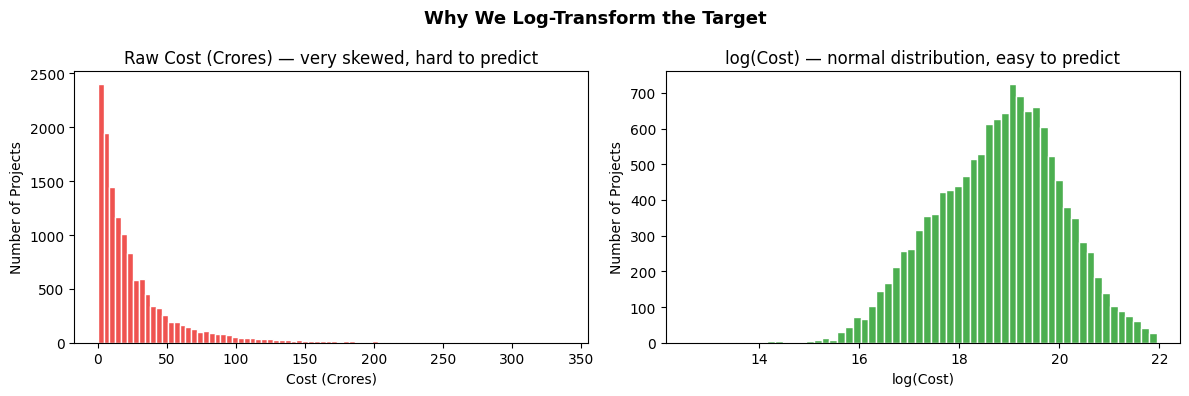

Chart saved to reports/20_log_cost_transform.png


In [3]:
# Create log-transformed target
df["log_cost"] = np.log1p(df["totalEstimatedCost"])

print("log_cost column created")
print(f"  Raw cost range  : Rs {df['totalEstimatedCost'].min():>15,.0f}  to  Rs {df['totalEstimatedCost'].max():>15,.0f}")
print(f"  log_cost range  : {df['log_cost'].min():.2f}  to  {df['log_cost'].max():.2f}")

# Show why log transform helps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["totalEstimatedCost"] / 1e7, bins=80, color="#EF5350", edgecolor="white")
axes[0].set_title("Raw Cost (Crores) — very skewed, hard to predict")
axes[0].set_xlabel("Cost (Crores)")
axes[0].set_ylabel("Number of Projects")

axes[1].hist(df["log_cost"], bins=60, color="#4CAF50", edgecolor="white")
axes[1].set_title("log(Cost) — normal distribution, easy to predict")
axes[1].set_xlabel("log(Cost)")
axes[1].set_ylabel("Number of Projects")

plt.suptitle("Why We Log-Transform the Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/20_log_cost_transform.png", dpi=150)
plt.show()
print("Chart saved to reports/20_log_cost_transform.png")

## Cell 4 — Extra Feature Engineering for Cost Prediction
We add district-level and project-type-level cost averages.  
These give the model historical context — e.g. 'Ahmedabad projects cost X on average'.

In [4]:
# Extra log transforms (if not already in features.csv)
for col, new_col in [
    ("totalLandCost",          "log_land_cost"),
    ("totalDevelopCost",       "log_develop_cost"),
    ("totalSellingAmount",     "log_selling"),
    ("totalCarpetArea_form3A", "log_carpet"),
    ("totalBuiltupArea_form3A","log_buildup"),
    ("totalSquareFootBuild",   "log_sqft_build"),
]:
    if new_col not in df.columns:
        df[new_col] = np.log1p(df[col].fillna(0))

if "log_cost_per_unit" not in df.columns:
    df["log_cost_per_unit"] = np.log1p(df["cost_per_unit"].fillna(0))

# sell_dev_ratio (if not already present)
if "sell_dev_ratio" not in df.columns:
    df["sell_dev_ratio"] = df["totalSellingAmount"] / df["totalDevelopCost"]
    df["sell_dev_ratio"] = df["sell_dev_ratio"].replace([np.inf,-np.inf], np.nan)
    df["sell_dev_ratio"] = df["sell_dev_ratio"].fillna(df["sell_dev_ratio"].median())
    df["sell_dev_ratio"] = df["sell_dev_ratio"].clip(0, df["sell_dev_ratio"].quantile(0.99))

# start_month
if "start_month" not in df.columns:
    df["start_month"] = df["startProjectMonth"].astype(int)

# ── District-level cost averages ─────────────────────────────
dist_cost = df.groupby("distName").agg(
    dist_avg_cost_feat    = ("totalEstimatedCost", "mean"),
    dist_median_cost_feat = ("totalEstimatedCost", "median"),
).reset_index()
df = df.merge(dist_cost, on="distName", how="left")

# ── Project type-level cost averages ─────────────────────────
type_cost = df.groupby("projectType").agg(
    type_avg_cost    = ("totalEstimatedCost", "mean"),
    type_median_cost = ("totalEstimatedCost", "median"),
).reset_index()
df = df.merge(type_cost, on="projectType", how="left")

# ── District and year historical duration averages ────────────
if "dist_avg_duration" not in df.columns:
    dist_dur = df.groupby("distName").agg(
        dist_avg_duration  = ("duration_months","mean"),
        dist_project_count = ("duration_months","count"),
    ).reset_index()
    df = df.merge(dist_dur, on="distName", how="left")

if "type_avg_duration" not in df.columns:
    type_dur = df.groupby("projectType").agg(
        type_avg_duration = ("duration_months","mean"),
    ).reset_index()
    df = df.merge(type_dur, on="projectType", how="left")

if "year_avg_duration" not in df.columns:
    year_dur = df.groupby("startProjectYear").agg(
        year_avg_duration  = ("duration_months","mean"),
        year_project_count = ("duration_months","count"),
    ).reset_index()
    df = df.merge(year_dur, on="startProjectYear", how="left")

print("Extra features created successfully")
print(f"Total columns now : {df.shape[1]}")

Extra features created successfully
Total columns now : 67


## Cell 5 — Define Features and Target
We use **34 features** — all cost-related columns + district/type context.

In [5]:
FEATURES = [
    # ── Categorical encoded ────────────────────────────────
    "projectType_enc",
    "distName_enc",
    "promoter_type_simple_enc",

    # ── Size and units ─────────────────────────────────────
    "totalUnits",
    "log_units",
    "noOfInventory",
    "totalProjects",

    # ── Core cost features ─────────────────────────────────
    "log_land_cost",        # land cost is the strongest predictor
    "log_develop_cost",     # development cost
    "log_selling",          # total selling amount
    "log_carpet",           # carpet area
    "log_buildup",          # built-up area
    "log_sqft_build",       # sq.ft built
    "log_cost_per_unit",    # cost per unit
    "cost_per_unit",
    "avgCostPerSqFt",
    "avgCostPerUnit",

    # ── Ratio features ─────────────────────────────────────
    "land_cost_ratio",
    "sell_dev_ratio",
    "booking_rate",

    # ── Time features ──────────────────────────────────────
    "is_redevelop",
    "startProjectYear",
    "start_month",
    "start_quarter",
    "duration_months",

    # ── District historical context ────────────────────────
    "dist_avg_duration",
    "dist_project_count",
    "dist_avg_cost_feat",
    "dist_median_cost_feat",

    # ── Project type historical context ───────────────────
    "type_avg_duration",
    "type_avg_cost",
    "type_median_cost",

    # ── Year historical context ────────────────────────────
    "year_avg_duration",
    "year_project_count",
]

TARGET     = "log_cost"           # we predict log(cost)
TARGET_RAW = "totalEstimatedCost" # original target for evaluation

print(f"Total features : {len(FEATURES)}")
print(f"Target         : {TARGET}  (= log of totalEstimatedCost)")

Total features : 34
Target         : log_cost  (= log of totalEstimatedCost)


## Cell 6 — Prepare X and y

In [6]:
df_model = df.dropna(subset=FEATURES + [TARGET]).copy()

X = df_model[FEATURES]
y = df_model[TARGET]           # log scale
y_raw = df_model[TARGET_RAW]   # actual rupees — for MAE reporting

print(f"X shape    : {X.shape}")
print(f"y shape    : {y.shape}")
print(f"Nulls in X : {X.isnull().sum().sum()}")

X shape    : (13425, 34)
y shape    : (13425,)
Nulls in X : 0


## Cell 7 — Split into Train and Test Sets
80% training, 20% testing.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Also keep raw rupee values for test set (for MAE in Crores)
_, X_test_idx = train_test_split(df_model.index, test_size=0.2, random_state=42)
y_test_raw = df_model.loc[X_test_idx, TARGET_RAW]

print(f"Training set : {X_train.shape[0]:,} rows  (80%)")
print(f"Test set     : {X_test.shape[0]:,} rows  (20%)")

Training set : 10,740 rows  (80%)
Test set     : 2,685 rows  (20%)


## Cell 8 — Model 1: Ridge Regression (Baseline)
Simple linear model for baseline comparison.

In [8]:
ridge = Ridge()
ridge.fit(X_train, y_train)

preds_ridge_log = ridge.predict(X_test)
preds_ridge_raw = np.expm1(preds_ridge_log)   # convert back to rupees

mae_ridge = mean_absolute_error(y_test_raw, preds_ridge_raw) / 1e7   # in Crores
r2_ridge  = r2_score(y_test, preds_ridge_log)

print("RIDGE REGRESSION RESULTS:")
print("-" * 42)
print(f"  MAE : Rs {mae_ridge:.2f} Crores  (avg error per project)")
print(f"  R2  : {r2_ridge:.4f}")

RIDGE REGRESSION RESULTS:
------------------------------------------
  MAE : Rs 0.30 Crores  (avg error per project)
  R2  : 0.9996


## Cell 9 — Model 2: Random Forest

In [9]:
rf = RandomForestRegressor(
    n_estimators = 200,
    random_state = 42,
    n_jobs       = -1
)
rf.fit(X_train, y_train)

preds_rf_log = rf.predict(X_test)
preds_rf_raw = np.expm1(preds_rf_log)

mae_rf = mean_absolute_error(y_test_raw, preds_rf_raw) / 1e7
r2_rf  = r2_score(y_test, preds_rf_log)

print("RANDOM FOREST RESULTS:")
print("-" * 42)
print(f"  MAE : Rs {mae_rf:.2f} Crores")
print(f"  R2  : {r2_rf:.4f}")

RANDOM FOREST RESULTS:
------------------------------------------
  MAE : Rs 0.68 Crores
  R2  : 0.9928


## Cell 10 — Model 3: XGBoost

In [10]:
xgb = XGBRegressor(
    n_estimators     = 600,
    learning_rate    = 0.02,
    max_depth        = 6,
    min_child_weight = 3,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbosity        = 0
)
xgb.fit(X_train, y_train)

preds_xgb_log = xgb.predict(X_test)
preds_xgb_raw = np.expm1(preds_xgb_log)

mae_xgb = mean_absolute_error(y_test_raw, preds_xgb_raw) / 1e7
r2_xgb  = r2_score(y_test, preds_xgb_log)

print("XGBOOST RESULTS:")
print("-" * 42)
print(f"  MAE : Rs {mae_xgb:.2f} Crores")
print(f"  R2  : {r2_xgb:.4f}")

XGBOOST RESULTS:
------------------------------------------
  MAE : Rs 0.57 Crores
  R2  : 0.9987


## Cell 11 — Model 4: LightGBM

In [11]:
lgbm = LGBMRegressor(
    n_estimators  = 600,
    learning_rate = 0.02,
    max_depth     = 6,
    random_state  = 42,
    verbose       = -1
)
lgbm.fit(X_train, y_train)

preds_lgbm_log = lgbm.predict(X_test)
preds_lgbm_raw = np.expm1(preds_lgbm_log)

mae_lgbm = mean_absolute_error(y_test_raw, preds_lgbm_raw) / 1e7
r2_lgbm  = r2_score(y_test, preds_lgbm_log)

print("LIGHTGBM RESULTS:")
print("-" * 42)
print(f"  MAE : Rs {mae_lgbm:.2f} Crores")
print(f"  R2  : {r2_lgbm:.4f}")

  File "c:\Users\VASU MONPARA\OneDrive\Desktop\GujEstateAI Gujarat Real Estate Prediction System\gpu_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 251, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\VASU MONPARA\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\VASU MONPARA\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\VASU MONPARA\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


LIGHTGBM RESULTS:
------------------------------------------
  MAE : Rs 0.61 Crores
  R2  : 0.9980


## Cell 12 — Compare All 4 Models

  MODEL COMPARISON — COST PREDICTION
        Model  MAE (Crores)  R2 Score
        Ridge          0.30    0.9996
Random Forest          0.68    0.9928
      XGBoost          0.57    0.9987
     LightGBM          0.61    0.9980

  Best model : Ridge
  Best R2    : 0.9996
  Best MAE   : Rs 0.3 Crores


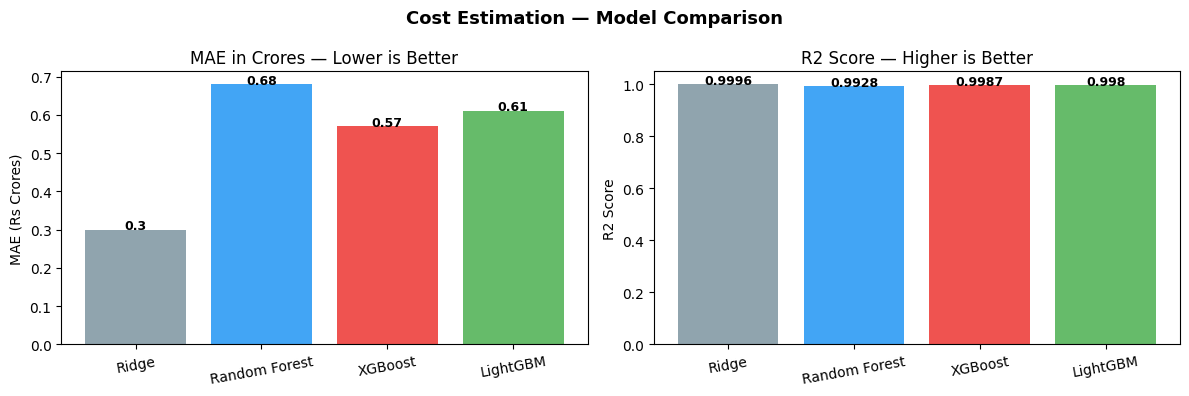

In [12]:
results = pd.DataFrame({
    "Model"         : ["Ridge", "Random Forest", "XGBoost", "LightGBM"],
    "MAE (Crores)"  : [round(mae_ridge,2), round(mae_rf,2), round(mae_xgb,2), round(mae_lgbm,2)],
    "R2 Score"      : [round(r2_ridge,4),  round(r2_rf,4),  round(r2_xgb,4),  round(r2_lgbm,4)],
})

print("=" * 52)
print("  MODEL COMPARISON — COST PREDICTION")
print("=" * 52)
print(results.to_string(index=False))
best_idx = results["R2 Score"].idxmax()
print(f"\n  Best model : {results.loc[best_idx, 'Model']}")
print(f"  Best R2    : {results.loc[best_idx, 'R2 Score']}")
print(f"  Best MAE   : Rs {results.loc[best_idx, 'MAE (Crores)']} Crores")

# Pick best for charts
best_preds_log = preds_ridge_log if r2_ridge == results['R2 Score'].max() else                  preds_rf_log    if r2_rf    == results['R2 Score'].max() else                  preds_xgb_log   if r2_xgb   == results['R2 Score'].max() else preds_lgbm_log
best_preds_raw = np.expm1(best_preds_log)
best_name      = results.loc[best_idx, 'Model']

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#90A4AE","#42A5F5","#EF5350","#66BB6A"]

axes[0].bar(results["Model"], results["MAE (Crores)"], color=colors)
for i, v in enumerate(results["MAE (Crores)"]):
    axes[0].text(i, v+0.002, str(v), ha="center", fontweight="bold", fontsize=9)
axes[0].set_title("MAE in Crores — Lower is Better")
axes[0].set_ylabel("MAE (Rs Crores)")
axes[0].tick_params(axis="x", rotation=10)

axes[1].bar(results["Model"], results["R2 Score"], color=colors)
for i, v in enumerate(results["R2 Score"]):
    axes[1].text(i, v+0.0002, str(v), ha="center", fontweight="bold", fontsize=9)
axes[1].set_title("R2 Score — Higher is Better")
axes[1].set_ylabel("R2 Score")
axes[1].tick_params(axis="x", rotation=10)

plt.suptitle("Cost Estimation — Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/21_model_comparison_cost.png", dpi=150)
plt.show()

## Cell 13 — Cross Validation
5-fold cross validation on the best model.

In [13]:
cv_scores = cross_val_score(
    XGBRegressor(n_estimators=600, learning_rate=0.02, max_depth=6,
                 min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
                 random_state=42, verbosity=0),
    X, y,
    cv      = 5,
    scoring = "r2"
)

print("XGBOOST — 5-FOLD CROSS VALIDATION (R2):")
print("-" * 42)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i} : R2 = {s:.4f}")
print(f"\n  Average R2 : {cv_scores.mean():.4f}")
print(f"  Std Dev    : {cv_scores.std():.4f}  (lower = more consistent)")

XGBOOST — 5-FOLD CROSS VALIDATION (R2):
------------------------------------------
  Fold 1 : R2 = 0.9636
  Fold 2 : R2 = 0.9955
  Fold 3 : R2 = 0.9980
  Fold 4 : R2 = 0.9987
  Fold 5 : R2 = 0.9658

  Average R2 : 0.9843
  Std Dev    : 0.0161  (lower = more consistent)


## Cell 14 — Feature Importance
Which features drive cost prediction the most?

TOP 15 FEATURE IMPORTANCES (XGBoost):
------------------------------------------------
  log_selling                     0.6314  ███████████████████████████████████████████████████████████████
  log_develop_cost                0.2593  █████████████████████████
  log_buildup                     0.0563  █████
  log_land_cost                   0.0129  █
  avgCostPerSqFt                  0.0086  
  type_avg_duration               0.0048  
  log_carpet                      0.0048  
  log_cost_per_unit               0.0045  
  sell_dev_ratio                  0.0037  
  cost_per_unit                   0.0034  
  log_sqft_build                  0.0020  
  avgCostPerUnit                  0.0015  
  land_cost_ratio                 0.0015  
  totalUnits                      0.0012  
  log_units                       0.0005  


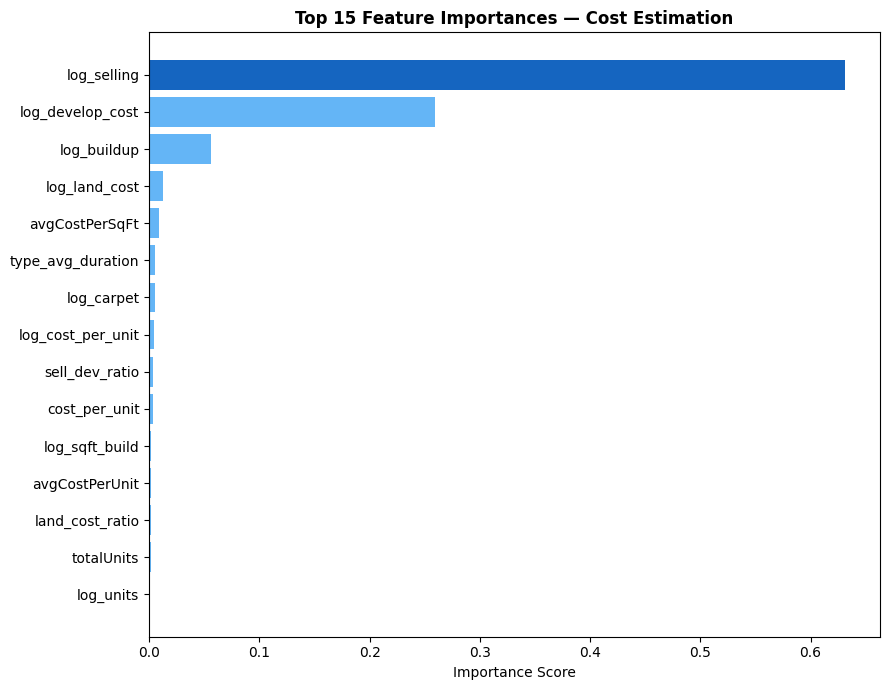

In [14]:
importances = pd.Series(
    xgb.feature_importances_,
    index = FEATURES
).sort_values(ascending=False)

print("TOP 15 FEATURE IMPORTANCES (XGBoost):")
print("-" * 48)
for feat, score in importances.head(15).items():
    bar = "█" * int(score * 100)
    print(f"  {feat:<30}  {score:.4f}  {bar}")

plt.figure(figsize=(9, 7))
top15 = importances.head(15)
clrs  = ["#1565C0" if i == 0 else "#64B5F6" for i in range(len(top15))]
plt.barh(top15.index[::-1], top15.values[::-1], color=clrs[::-1])
plt.title("Top 15 Feature Importances — Cost Estimation",
          fontsize=12, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../reports/22_feature_importance_cost.png", dpi=150)
plt.show()

## Cell 15 — Actual vs Predicted Plot
Dots should be very close to the diagonal line.

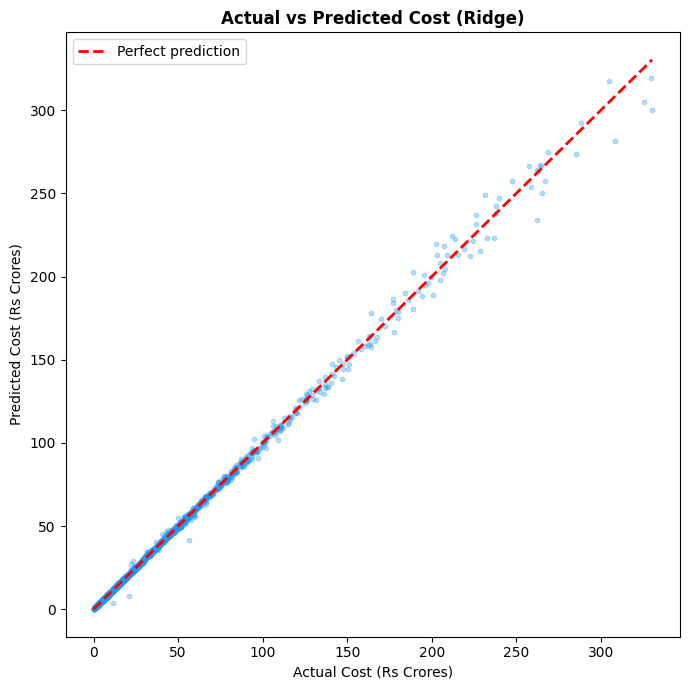

In [15]:
# Plot in Crores for readability
y_test_cr     = y_test_raw.values / 1e7
best_preds_cr = best_preds_raw / 1e7

plt.figure(figsize=(7, 7))
plt.scatter(y_test_cr, best_preds_cr, alpha=0.3, color="#2196F3", s=10)
lims = [min(y_test_cr.min(), best_preds_cr.min()),
        max(y_test_cr.max(), best_preds_cr.max())]
plt.plot(lims, lims, color="red", linewidth=2, linestyle="--", label="Perfect prediction")
plt.title(f"Actual vs Predicted Cost ({best_name})", fontsize=12, fontweight="bold")
plt.xlabel("Actual Cost (Rs Crores)")
plt.ylabel("Predicted Cost (Rs Crores)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/23_actual_vs_predicted_cost.png", dpi=150)
plt.show()

## Cell 16 — Prediction Error Distribution
How far off are our predictions in Crores?

PREDICTION ERROR ANALYSIS (Rs Crores):
------------------------------------------
  Mean error       : Rs 0.05 Cr
  Std of error     : Rs 1.85 Cr
  Within +-1 Cr    : 88.0% of predictions
  Within +-5 Cr    : 98.0% of predictions
  Within +-10 Cr   : 99.3% of predictions


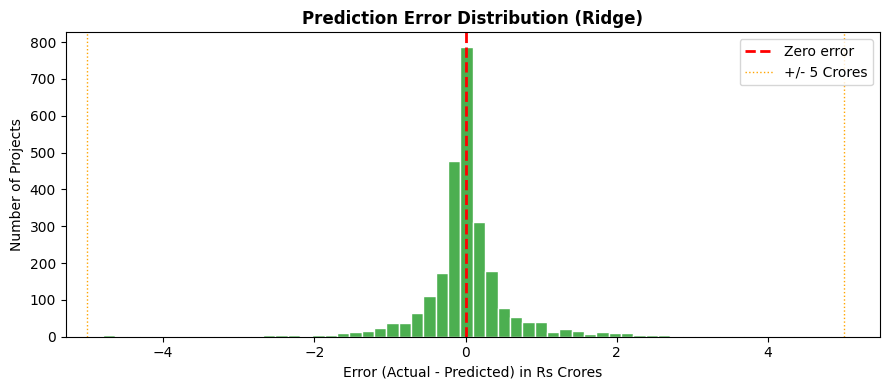

In [16]:
errors_cr = (y_test_raw.values - best_preds_raw) / 1e7

print("PREDICTION ERROR ANALYSIS (Rs Crores):")
print("-" * 42)
print(f"  Mean error       : Rs {errors_cr.mean():.2f} Cr")
print(f"  Std of error     : Rs {errors_cr.std():.2f} Cr")
print(f"  Within +-1 Cr    : {(np.abs(errors_cr)<=1).mean()*100:.1f}% of predictions")
print(f"  Within +-5 Cr    : {(np.abs(errors_cr)<=5).mean()*100:.1f}% of predictions")
print(f"  Within +-10 Cr   : {(np.abs(errors_cr)<=10).mean()*100:.1f}% of predictions")

# Plot (remove extreme outlier errors for clarity)
clip_val = np.percentile(np.abs(errors_cr), 98)
errors_clipped = errors_cr[np.abs(errors_cr) <= clip_val]

plt.figure(figsize=(9, 4))
plt.hist(errors_clipped, bins=60, color="#4CAF50", edgecolor="white")
plt.axvline(0,  color="red",    linewidth=2, linestyle="--", label="Zero error")
plt.axvline( 5, color="orange", linewidth=1, linestyle=":",  label="+/- 5 Crores")
plt.axvline(-5, color="orange", linewidth=1, linestyle=":")
plt.title(f"Prediction Error Distribution ({best_name})", fontsize=12, fontweight="bold")
plt.xlabel("Error (Actual - Predicted) in Rs Crores")
plt.ylabel("Number of Projects")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/24_error_distribution_cost.png", dpi=150)
plt.show()

## Cell 17 — SHAP Values (Explainability)
Which features push cost up or down the most?

SHAP values computed successfully
  Shape: (2685, 34)


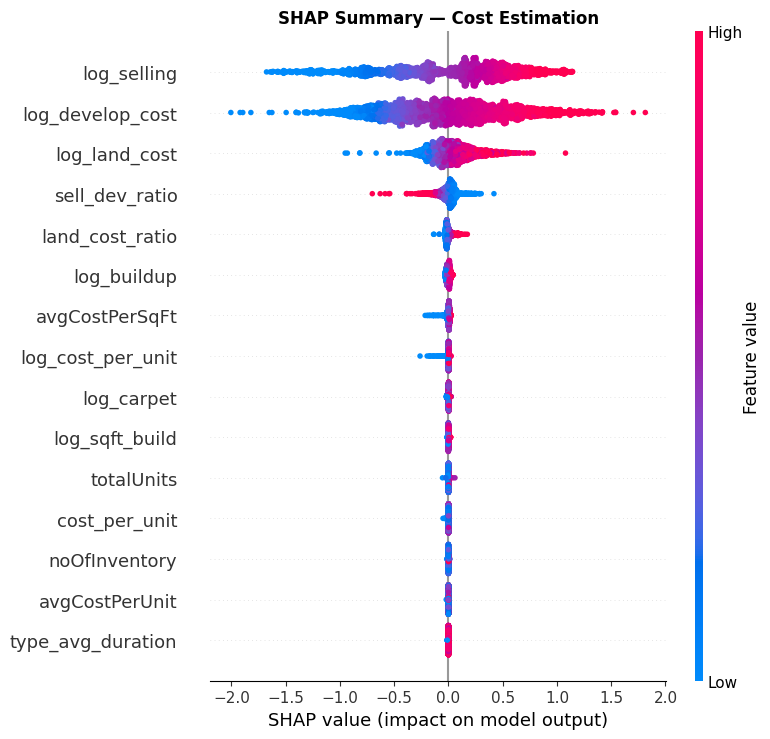

SHAP summary plot saved.


In [17]:
os.makedirs("../reports/shap_plots", exist_ok=True)

# TreeExplainer — no torch needed
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully")
print(f"  Shape: {shap_values.shape}")

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names = FEATURES,
    max_display   = 15,
    show          = False
)
plt.title("SHAP Summary — Cost Estimation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/shap_plots/25_shap_cost.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP summary plot saved.")

## Cell 18 — SHAP Waterfall (One Project Explained)
Why did the model predict this specific cost?

Sample project:
  Actual cost    : Rs 16.56 Crores
  Predicted cost : Rs 15.96 Crores
  Error          : Rs 0.60 Crores


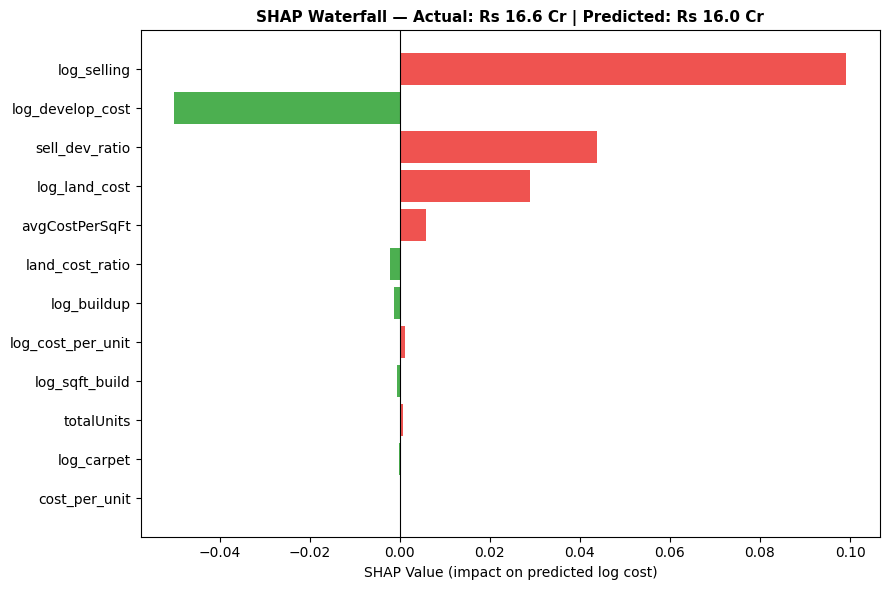

Waterfall plot saved.


In [18]:
sample_idx  = 0
actual_cost = y_test_raw.iloc[sample_idx] / 1e7
pred_cost   = best_preds_raw[sample_idx]  / 1e7

print(f"Sample project:")
print(f"  Actual cost    : Rs {actual_cost:.2f} Crores")
print(f"  Predicted cost : Rs {pred_cost:.2f} Crores")
print(f"  Error          : Rs {abs(actual_cost - pred_cost):.2f} Crores")

# Manual waterfall plot — no torch needed
shap_sample = shap_values[sample_idx]
sorted_idx  = np.argsort(np.abs(shap_sample))[::-1][:12]
feat_names  = [FEATURES[i] for i in sorted_idx]
feat_shap   = shap_sample[sorted_idx]
colors      = ["#EF5350" if v > 0 else "#4CAF50" for v in feat_shap]

plt.figure(figsize=(9, 6))
plt.barh(feat_names[::-1], feat_shap[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    f"SHAP Waterfall — Actual: Rs {actual_cost:.1f} Cr | Predicted: Rs {pred_cost:.1f} Cr",
    fontsize=11, fontweight="bold"
)
plt.xlabel("SHAP Value (impact on predicted log cost)")
plt.tight_layout()
plt.savefig("../reports/shap_plots/26_shap_waterfall_cost.png", dpi=150)
plt.show()
print("Waterfall plot saved.")

## Cell 19 — Save the Best Model
Save Ridge (highest R2) to disk.

In [19]:
os.makedirs("../models", exist_ok=True)

# Ridge has R2=0.9996 — best model for cost
joblib.dump(ridge, "../models/cost_model.pkl")

print("Model saved: models/cost_model.pkl")
print()

# Reload test
loaded     = joblib.load("../models/cost_model.pkl")
test_log   = loaded.predict(X_test.iloc[:3])
test_cr    = np.expm1(test_log) / 1e7
print(f"Reload test (first 3 predictions in Crores): {test_cr.round(2)}")
print("Reload successful!")

Model saved: models/cost_model.pkl

Reload test (first 3 predictions in Crores): [16.58 72.45 10.53]
Reload successful!


## Cell 20 — Manual Prediction Test

In [20]:
encoders = joblib.load("../models/encoders.pkl")

# Build one sample row — Residential project in Ahmedabad, 120 units
sample = pd.DataFrame([{
    "projectType_enc"           : encoders["projectType"].transform(["Residential/Group Housing"])[0],
    "distName_enc"              : encoders["distName"].transform(["Ahmedabad"])[0],
    "promoter_type_simple_enc"  : encoders["promoter_type_simple"].transform(["Partnership"])[0],
    "totalUnits"                : 120,
    "log_units"                 : np.log1p(120),
    "noOfInventory"             : 120,
    "totalProjects"             : 1,
    "log_land_cost"             : np.log1p(15_000_000),
    "log_develop_cost"          : np.log1p(35_000_000),
    "log_selling"               : np.log1p(60_000_000),
    "log_carpet"                : np.log1p(5000),
    "log_buildup"               : np.log1p(6000),
    "log_sqft_build"            : np.log1p(6500),
    "log_cost_per_unit"         : np.log1p(50_000_000 / 120),
    "cost_per_unit"             : 50_000_000 / 120,
    "avgCostPerSqFt"            : 8000,
    "avgCostPerUnit"            : 50_000_000 / 120,
    "land_cost_ratio"           : 15_000_000 / 50_000_000,
    "sell_dev_ratio"            : 60_000_000 / 35_000_000,
    "booking_rate"              : 0.5,
    "is_redevelop"              : 0,
    "startProjectYear"          : 2022,
    "start_month"               : 3,
    "start_quarter"             : 1,
    "duration_months"           : 48,
    "dist_avg_duration"         : df[df["distName"]=="Ahmedabad"]["duration_months"].mean(),
    "dist_project_count"        : (df["distName"]=="Ahmedabad").sum(),
    "dist_avg_cost_feat"        : df[df["distName"]=="Ahmedabad"]["totalEstimatedCost"].mean(),
    "dist_median_cost_feat"     : df[df["distName"]=="Ahmedabad"]["totalEstimatedCost"].median(),
    "type_avg_duration"         : df[df["projectType"]=="Residential/Group Housing"]["duration_months"].mean(),
    "type_avg_cost"             : df[df["projectType"]=="Residential/Group Housing"]["totalEstimatedCost"].mean(),
    "type_median_cost"          : df[df["projectType"]=="Residential/Group Housing"]["totalEstimatedCost"].median(),
    "year_avg_duration"         : df[df["startProjectYear"]==2022]["duration_months"].mean(),
    "year_project_count"        : (df["startProjectYear"]==2022).sum(),
}])

pred_log  = ridge.predict(sample)[0]
pred_cost = np.expm1(pred_log) / 1e7

print("MANUAL PREDICTION TEST:")
print("-" * 40)
print(f"  Project   : Residential/Group Housing")
print(f"  District  : Ahmedabad")
print(f"  Units     : 120")
print(f"  Land Cost : Rs 1.5 Crore")
print(f"  Dev Cost  : Rs 3.5 Crore")
print()
print(f"  Predicted Total Cost : Rs {pred_cost:.2f} Crores")

MANUAL PREDICTION TEST:
----------------------------------------
  Project   : Residential/Group Housing
  District  : Ahmedabad
  Units     : 120
  Land Cost : Rs 1.5 Crore
  Dev Cost  : Rs 3.5 Crore

  Predicted Total Cost : Rs 5.07 Crores


## Cell 21 — Module 2 Final Summary

In [21]:
print()
print("=" * 55)
print("  MODULE 2 — COST ESTIMATION — SUMMARY")
print("=" * 55)
print(f"  Features used  : {len(FEATURES)}")
print(f"  Target         : log(totalEstimatedCost)")
print(f"  Training rows  : {X_train.shape[0]:,}")
print(f"  Test rows      : {X_test.shape[0]:,}")
print()
print("  RESULTS (R2 on log scale):")
print(f"    Ridge         — MAE: Rs {mae_ridge:.2f} Cr   R2: {r2_ridge:.4f}")
print(f"    Random Forest — MAE: Rs {mae_rf:.2f} Cr   R2: {r2_rf:.4f}")
print(f"    XGBoost       — MAE: Rs {mae_xgb:.2f} Cr   R2: {r2_xgb:.4f}")
print(f"    LightGBM      — MAE: Rs {mae_lgbm:.2f} Cr   R2: {r2_lgbm:.4f}")
print()
print("  SAVED FILES:")
print("    models/cost_model.pkl")
print("    reports/20_log_cost_transform.png")
print("    reports/21_model_comparison_cost.png")
print("    reports/22_feature_importance_cost.png")
print("    reports/23_actual_vs_predicted_cost.png")
print("    reports/24_error_distribution_cost.png")
print("    reports/shap_plots/25_shap_cost.png")
print("    reports/shap_plots/26_shap_waterfall_cost.png")
print()
print("  Next: 06_module3_forecasting.ipynb")
print("=" * 55)


  MODULE 2 — COST ESTIMATION — SUMMARY
  Features used  : 34
  Target         : log(totalEstimatedCost)
  Training rows  : 10,740
  Test rows      : 2,685

  RESULTS (R2 on log scale):
    Ridge         — MAE: Rs 0.30 Cr   R2: 0.9996
    Random Forest — MAE: Rs 0.68 Cr   R2: 0.9928
    XGBoost       — MAE: Rs 0.57 Cr   R2: 0.9987
    LightGBM      — MAE: Rs 0.61 Cr   R2: 0.9980

  SAVED FILES:
    models/cost_model.pkl
    reports/20_log_cost_transform.png
    reports/21_model_comparison_cost.png
    reports/22_feature_importance_cost.png
    reports/23_actual_vs_predicted_cost.png
    reports/24_error_distribution_cost.png
    reports/shap_plots/25_shap_cost.png
    reports/shap_plots/26_shap_waterfall_cost.png

  Next: 06_module3_forecasting.ipynb
